In [1]:
# ==========================
# Time Series Forecasting
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error

In [3]:
# --------------------------
# 1. Load Dataset
# --------------------------
df = pd.read_csv(r"C:\Users\cathr\Downloads\archive (9)\DailyDelhiClimateTrain.csv")
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
# Use Mean Temperature
series = df['meantemp']
print(df.head())

             meantemp   humidity  wind_speed  meanpressure
date                                                      
2013-01-01  10.000000  84.500000    0.000000   1015.666667
2013-01-02   7.400000  92.000000    2.980000   1017.800000
2013-01-03   7.166667  87.000000    4.633333   1018.666667
2013-01-04   8.666667  71.333333    1.233333   1017.166667
2013-01-05   6.000000  86.833333    3.700000   1016.500000


In [4]:
# --------------------------
# Split Data
# Last 7 days -> Test
# --------------------------

train = series[:-7]
test = series[-7:]


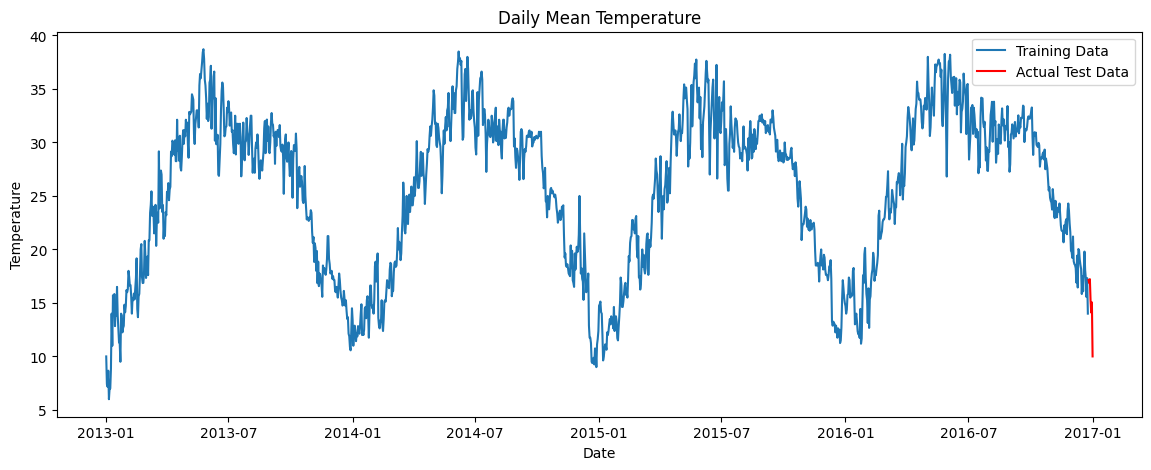

In [5]:
# --------------------------
# Visualize Time Series
# --------------------------

plt.figure(figsize=(14,5))
plt.plot(train,label='Training Data')
plt.plot(test,label='Actual Test Data',color='red')
plt.title("Daily Mean Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.show()

In [6]:
# --------------------------
# 2. ADF Test
# --------------------------

print("\nADF Test")
result = adfuller(train)
print("ADF Statistic :", result[0])
print("p-value :", result[1])
if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")



ADF Test
ADF Statistic : -2.1647560784846602
p-value : 0.2192846407247283
Series is Non-Stationary



ADF Test After Differencing
ADF Statistic : -16.456603200499902
p-value : 2.351289003122722e-29


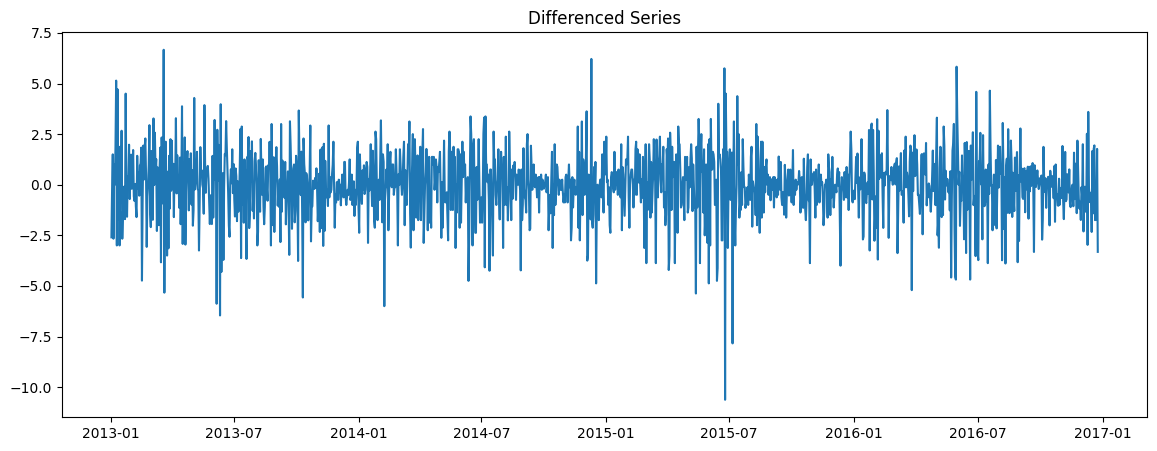

In [7]:
# --------------------------
# 3. Differencing
# --------------------------

diff_series = train.diff().dropna()

result2 = adfuller(diff_series)

print("\nADF Test After Differencing")

print("ADF Statistic :", result2[0])
print("p-value :", result2[1])

plt.figure(figsize=(14,5))
plt.plot(diff_series)
plt.title("Differenced Series")
plt.show()

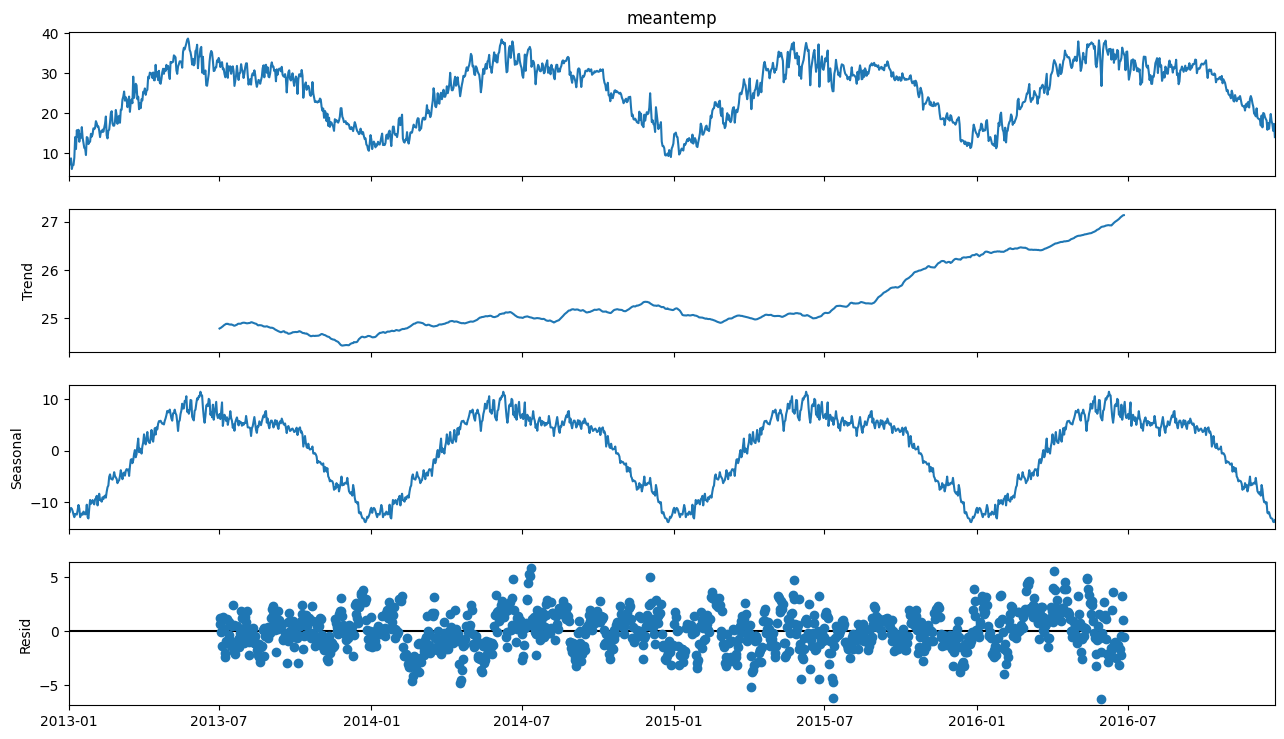

In [8]:

# --------------------------
# 4. Seasonal Decomposition
# --------------------------

decomposition = seasonal_decompose(train,
                                   model='additive',
                                   period=365)

fig = decomposition.plot()
fig.set_size_inches(14,8)
plt.show()



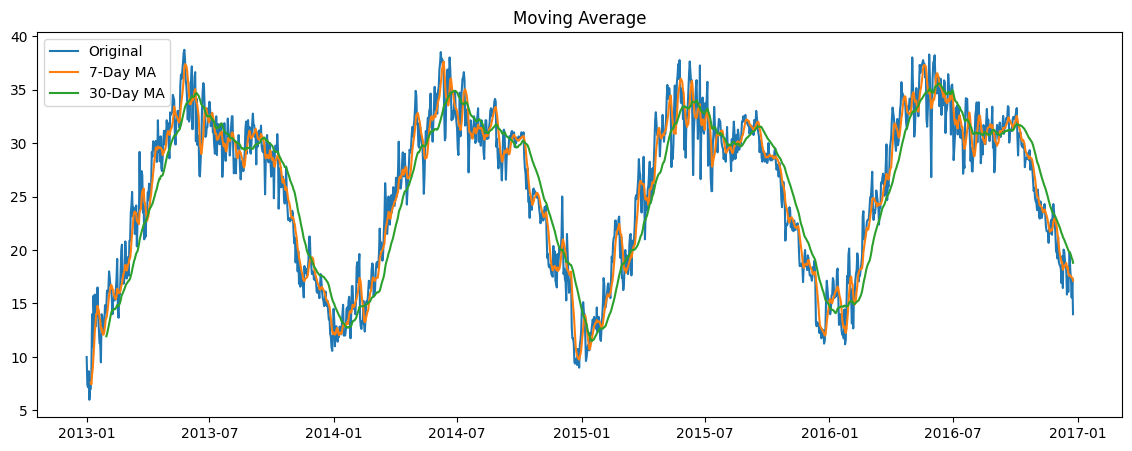

In [9]:
# --------------------------
# 5. Moving Average
# --------------------------

ma7 = train.rolling(window=7).mean()
ma30 = train.rolling(window=30).mean()

plt.figure(figsize=(14,5))

plt.plot(train,label='Original')
plt.plot(ma7,label='7-Day MA')
plt.plot(ma30,label='30-Day MA')

plt.title("Moving Average")
plt.legend()
plt.show()

In [10]:
# --------------------------
# 6. Forecast Next 7 Days
# --------------------------

# Naive Forecast

naive_forecast = np.repeat(train.iloc[-1],7)

# Moving Average Forecast

moving_forecast = []

history = list(train)

window = 7

for i in range(7):

    forecast = np.mean(history[-window:])
    moving_forecast.append(forecast)

    # append forecast for recursive prediction
    history.append(forecast)


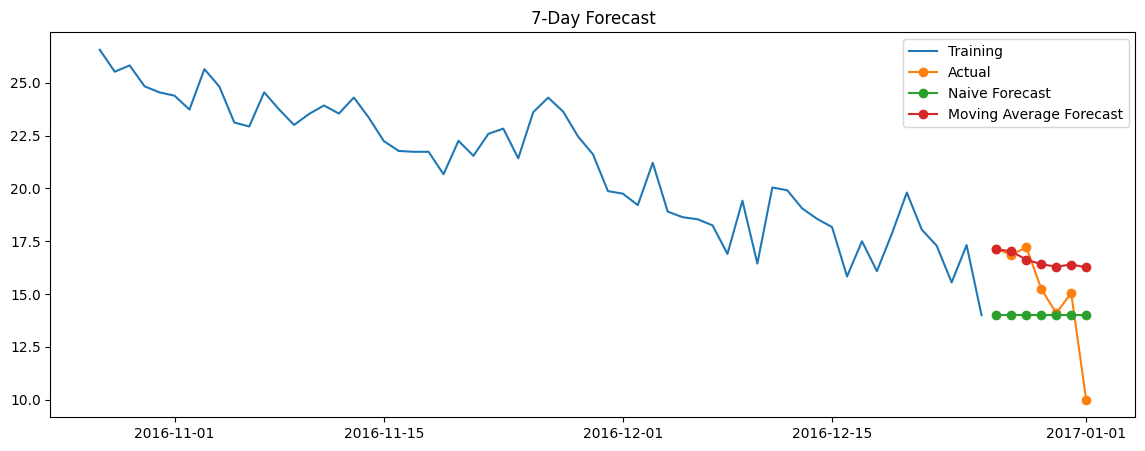

In [11]:
# --------------------------
# Plot Forecast
# --------------------------

plt.figure(figsize=(14,5))

plt.plot(train.index[-60:],train[-60:],label='Training')

plt.plot(test.index,test.values,
         label='Actual',
         marker='o')

plt.plot(test.index,
         naive_forecast,
         label='Naive Forecast',
         marker='o')

plt.plot(test.index,
         moving_forecast,
         label='Moving Average Forecast',
         marker='o')

plt.title("7-Day Forecast")

plt.legend()

plt.show()


In [12]:

# --------------------------
# 7. Calculate MAE
# --------------------------

naive_mae = mean_absolute_error(test,naive_forecast)

moving_mae = mean_absolute_error(test,moving_forecast)

print("\nForecast Errors")

print("Naive Forecast MAE :",round(naive_mae,3))

print("Moving Average MAE :",round(moving_mae,3))




Forecast Errors
Naive Forecast MAE : 2.228
Moving Average MAE : 1.682


In [13]:
# --------------------------
# Forecast Table
# --------------------------

forecast_df = pd.DataFrame({

    "Actual":test.values,
    "Naive Forecast":naive_forecast,
    "Moving Avg Forecast":moving_forecast

},index=test.index)

print("\nForecast Comparison")

print(forecast_df)


Forecast Comparison
               Actual  Naive Forecast  Moving Avg Forecast
date                                                      
2016-12-26  17.142857            14.0            17.123006
2016-12-27  16.850000            14.0            17.018129
2016-12-28  17.217391            14.0            16.620719
2016-12-29  15.238095            14.0            16.416536
2016-12-30  14.095238            14.0            16.292367
2016-12-31  15.052632            14.0            16.398420
2017-01-01  10.000000            14.0            16.267025
